# E05 · Gaussian processes and the HSGP approximation

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Silverman's motorcycle crash-test data: head acceleration against time after impact, 133 readings |
| **You will learn** | A GP as a prior over functions · lengthscale and amplitude priors that respect the data scale · exact inference with `pm.gp.Marginal` and `gp.conditional` · why exact GPs cost $O(n^3)$ · the Hilbert-space approximation `pm.gp.HSGP`: choosing `m` and `c`, centred vs non-centred coefficients, prediction with `pm.set_data`, freezing the data for speed · a second GP on the log-noise for a heteroskedastic model · PPC and LOO to show it matters |

Splines and polynomials make you choose a functional form. A Gaussian process lets you say
something weaker and more honest: *"the function is smooth, it varies by about this much,
and it changes on roughly this timescale"*. That is a prior over **functions**, and this
notebook builds one up from scratch, fits it exactly, then fits it *fast*, and finally uses
the speed to buy a better model.

In [1]:
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
from pymc.model.transform.optimization import freeze_dims_and_data

from pymc_challenges import data

RANDOM_SEED = 1985
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PreliZ {pz.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PreliZ 0.28.0


## 1 · Question and data

A dummy's head is fitted with an accelerometer and the motorcycle is crashed into a wall.
*What is the acceleration curve, and how variable are readings around it?* Helmet designers
care about both: the curve is the typical load, the scatter is what the helmet must survive.

In [2]:
data.describe("mcycle")
mcycle = data.load("mcycle")
mcycle.describe().round(1)

mcycle: Head acceleration (g) against time after impact (ms), 133 readings.
  source: Silverman (1985), simulated motorcycle crash experiment, via R package `MASS`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/MASS/mcycle.csv


,times,accel
count,133.0,133.0
mean,25.2,-25.5
std,13.1,48.3
min,2.4,-134.0
25%,15.6,-54.9
50%,23.4,-13.3
75%,34.8,0.0
max,57.6,75.0


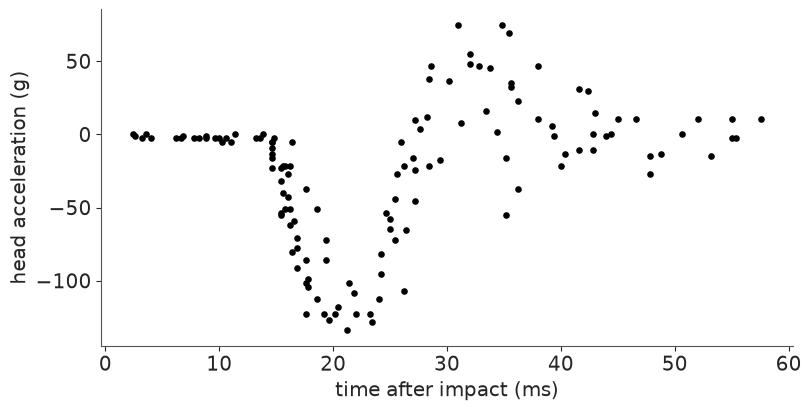

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(mcycle.times, mcycle.accel, s=14, color="k")
ax.set(xlabel="time after impact (ms)", ylabel="head acceleration (g)");

Three things to notice:

- The curve is flat, plunges to about -120 g, rebounds and settles. No low-order polynomial
  does that.
- **The scatter is not constant.** Before ~13 ms the readings sit within a few g of zero;
  after the impact they are spread over 50 g or more. Keep this in mind - the first models
  below ignore it, and section 7 is about what that costs.
- Several times carry more than one reading, which a GP handles without fuss.

We divide acceleration by its standard deviation so that "1" is a typical swing, but we do
**not** centre it: 0 g is the physically meaningful baseline before the impact, and a GP
with a zero mean function returns to 0 when it has no data - exactly what we want here.
Time stays in milliseconds so that the lengthscale is readable.

In [4]:
t = mcycle.times.to_numpy()
ACCEL_SD = mcycle.accel.std()
y = mcycle.accel.to_numpy() / ACCEL_SD

t_grid = np.linspace(0, 60, 200)
print(f"1 unit of y = {ACCEL_SD:.1f} g;  {len(t)} readings at {len(np.unique(t))} distinct times")

1 unit of y = 48.3 g;  133 readings at 94 distinct times


## 2 · A GP is a prior over functions

A Gaussian process says: for *any* set of inputs $t_1, \dots, t_n$, the function values
are jointly Normal,

$$f(t_1), \dots, f(t_n) \sim \text{MvNormal}\big(0,\ K\big), \qquad K_{ij} = k(t_i, t_j).$$

All the modelling is in the **kernel** $k$: it says how strongly two function values are
correlated as a function of how far apart their inputs are. We will use the Matérn 5/2 kernel

$$k(t, t') = \eta^2 \Big(1 + \tfrac{\sqrt5\, r}{\ell} + \tfrac{5 r^2}{3 \ell^2}\Big)
\exp\!\Big(-\tfrac{\sqrt5\, r}{\ell}\Big), \qquad r = |t - t'|,$$

which gives twice-differentiable functions - smooth, but not as unrealistically smooth as
the squared-exponential. It has two hyperparameters:

- the **amplitude** $\eta$: the prior standard deviation of $f$ at any point;
- the **lengthscale** $\ell$: how far you must move before the function "forgets" where it was.

The quickest way to understand them is to draw functions. A PyMC covariance object is
callable: `cov(X)` builds the matrix symbolically and `.eval()` gives NumPy.

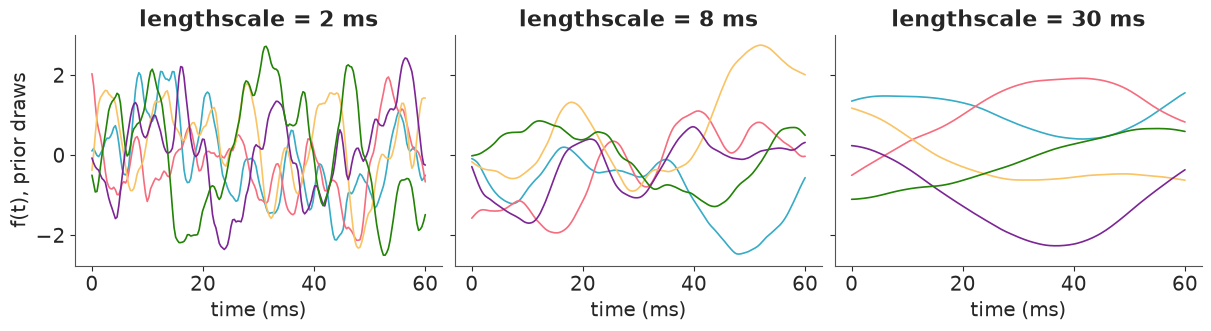

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, ls in zip(axes, [2, 8, 30]):
    cov = pm.gp.cov.Matern52(1, ls=ls)  # eta = 1
    K = cov(t_grid[:, None]).eval()
    draws = rng.multivariate_normal(np.zeros(len(t_grid)), K + 1e-8 * np.eye(len(t_grid)), size=5)
    ax.plot(t_grid, draws.T, lw=1.2)
    ax.set(title=f"lengthscale = {ls} ms", xlabel="time (ms)")
axes[0].set_ylabel("f(t), prior draws");

With $\ell = 2$ ms the functions wiggle faster than the accelerometer samples - such a GP
could chase every reading. With $\ell = 30$ ms (half the experiment) they are nearly straight
lines and could never produce the plunge-and-rebound. The truth is in between, and the
*data cannot tell us much outside that range*:

- lengthscales far **below** the spacing of the inputs are indistinguishable from noise;
- lengthscales far **above** the span of the inputs are indistinguishable from a constant or a line.

A flat or very wide prior on $\ell$ therefore leaves the posterior free to drift into regions
where the likelihood is flat - a classic source of bad GP fits.

## 3 · Priors that respect the data scale

For $\ell$ we want little mass below ~3 ms (the median gap between reading times is 0.4 ms, so this
is already several samples) and little above ~25 ms (the whole record is 55 ms). An
**inverse-gamma** is the usual choice because its left tail falls to zero *very* fast - it
firmly rules out tiny lengthscales - while the right tail is heavy and forgiving.

Rather than fiddle with `alpha` and `beta`, ask PreliZ for the maximum-entropy
inverse-gamma with 90% of its mass between 3 and 25:

InverseGamma(alpha=3.35, beta=32.8)
P(ell < 3) = 0.002,  P(ell > 25) = 0.098


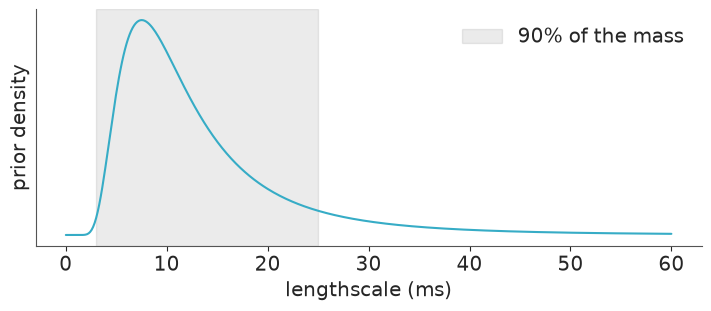

In [6]:
ell_prior = pz.maxent(pz.InverseGamma(), lower=3, upper=25, mass=0.9, plot=False)
ELL_ALPHA, ELL_BETA = float(ell_prior.alpha), float(ell_prior.beta)

print(ell_prior)
print("P(ell < 3) = %.3f,  P(ell > 25) = %.3f" % (ell_prior.cdf(3), 1 - ell_prior.cdf(25)))

fig, ax = plt.subplots(figsize=(7, 3))
grid = np.linspace(0.01, 60, 400)
ax.plot(grid, ell_prior.pdf(grid))
ax.axvspan(3, 25, color="k", alpha=0.08, label="90% of the mass")
ax.set(xlabel="lengthscale (ms)", ylabel="prior density", yticks=[])
ax.legend();

Note how the 10% that is left over is split: almost nothing below 3 ms, nearly all of it in
the right tail. That asymmetry is the point of the inverse-gamma.

For the amplitude, `y` is in standard-deviation units, so the curve's swings are of order 1:
`HalfNormal(1.5)` allows up to ~3 while preferring less. Same for the noise, `HalfNormal(1)`.

**Prior predictive check.** Do not take those words on trust - draw hyperparameters from the
priors, then a function for each, and look.

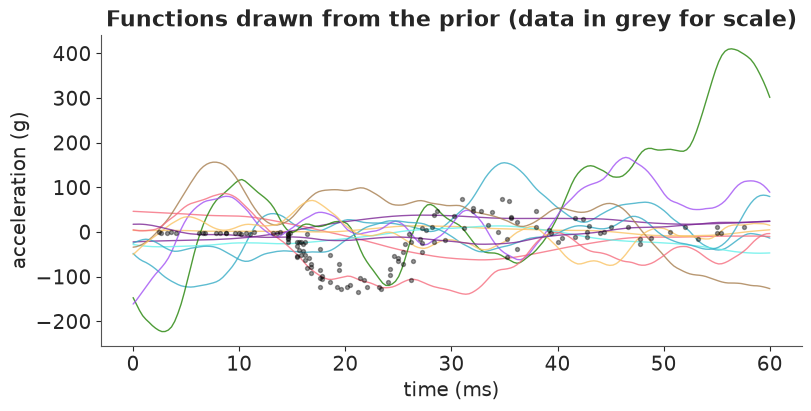

In [7]:
with pm.Model():
    ell_ = pm.InverseGamma("ell", alpha=ELL_ALPHA, beta=ELL_BETA)
    eta_ = pm.HalfNormal("eta", 1.5)
    ell_draws, eta_draws = pm.draw([ell_, eta_], draws=12, random_seed=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(8, 4))
for ell_i, eta_i in zip(ell_draws, eta_draws):
    K = (eta_i**2 * pm.gp.cov.Matern52(1, ls=ell_i))(t_grid[:, None]).eval()
    f_draw = rng.multivariate_normal(np.zeros(len(t_grid)), K + 1e-8 * np.eye(len(t_grid)))
    ax.plot(t_grid, f_draw * ACCEL_SD, lw=1, alpha=0.8)
ax.scatter(t, y * ACCEL_SD, s=8, color="k", alpha=0.4, zorder=3)
ax.set(xlabel="time (ms)", ylabel="acceleration (g)", title="Functions drawn from the prior (data in grey for scale)");

Most prior functions swing by tens to a couple of hundred g - the vertical scale of the
data - with the occasional larger one from the tail of the amplitude prior, and they change
on timescales from a few to a few tens of milliseconds. None of them looks like the data -
they are not supposed to - but the data's shape is clearly *within reach*. That is what a
weakly informative GP prior looks like.

## 4 · The exact GP: `pm.gp.Marginal`

With a Normal likelihood, $y_i = f(t_i) + \varepsilon_i$, $\varepsilon_i \sim \text{Normal}(0, \sigma)$,
the function values can be integrated out analytically:

$$y \sim \text{MvNormal}\big(0,\ K + \sigma^2 I\big).$$

`pm.gp.Marginal` implements exactly this. NUTS only has to explore the **three**
hyperparameters $(\ell, \eta, \sigma)$; the 133 function values never appear as parameters.

In [8]:
with pm.Model() as exact_model:
    ell = pm.InverseGamma("ell", alpha=ELL_ALPHA, beta=ELL_BETA)
    eta = pm.HalfNormal("eta", 1.5)
    sigma = pm.HalfNormal("sigma", 1)

    cov = eta**2 * pm.gp.cov.Matern52(1, ls=ell)
    gp_exact = pm.gp.Marginal(cov_func=cov)
    gp_exact.marginal_likelihood("y", X=t[:, None], y=y, sigma=sigma)

    start = time.time()
    exact_idata = pm.sample(random_seed=RANDOM_SEED)
    exact_seconds = time.time() - start

print("divergences:", int(exact_idata.sample_stats["diverging"].sum()))
az.summary(exact_idata, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [ell, eta, sigma]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,7.62,1.74,4.48,10.71,1498.18,1609.46,1.0,0.05,0.03
eta,1.21,0.40,0.60,1.91,1494.06,1669.48,1.0,0.01,0.01
sigma,0.47,0.03,0.42,0.53,3096.31,2842.19,1.0,0.00,0.00


Clean diagnostics. The lengthscale is around 7 ms, comfortably inside the prior's bulk, and
the noise is just under half a standard deviation of `y`.

### Predicting: `gp.conditional`

The function was integrated out, so to see it we must bring it back. Conditional on the
hyperparameters and the data, $f$ at *new* inputs is again multivariate Normal, with the
textbook GP mean and covariance. `gp.conditional` adds that distribution to the model, and
`pm.sample_posterior_predictive` draws from it once per posterior draw of the
hyperparameters. `pred_noise=True` gives new *readings* instead of the latent curve.

In [9]:
with exact_model:
    gp_exact.conditional("f_new", Xnew=t_grid[:, None])
    gp_exact.conditional("y_new", Xnew=t_grid[:, None], pred_noise=True)
    exact_pred = pm.sample_posterior_predictive(
        exact_idata, var_names=["f_new", "y_new"], random_seed=RANDOM_SEED
    )

Sampling: [f_new, y_new]


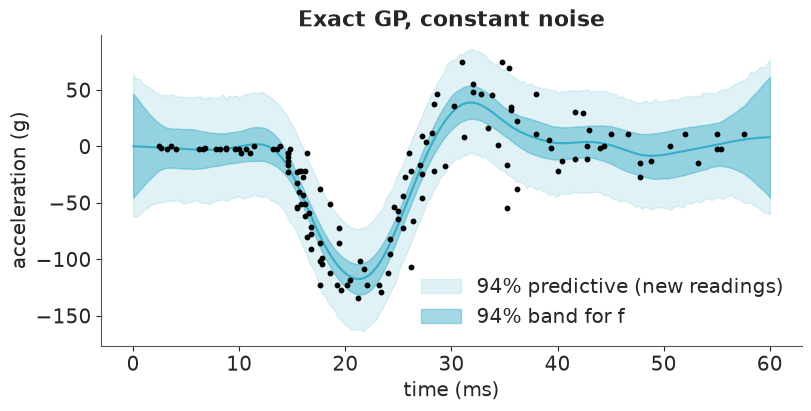

In [10]:
def band(da, prob=0.94):
    """Mean and central interval over (chain, draw), rescaled to g."""
    lo, hi = da.quantile([(1 - prob) / 2, (1 + prob) / 2], dim=("chain", "draw")).to_numpy()
    return da.mean(("chain", "draw")).to_numpy() * ACCEL_SD, lo * ACCEL_SD, hi * ACCEL_SD


def plot_fit(f_da, y_da, ax, color="C0", title=None):
    """Latent curve (dark band) and predictive interval for new readings (light band)."""
    f_mean, f_lo, f_hi = band(f_da)
    _, y_lo, y_hi = band(y_da)
    ax.fill_between(t_grid, y_lo, y_hi, color=color, alpha=0.15, label="94% predictive (new readings)")
    ax.fill_between(t_grid, f_lo, f_hi, color=color, alpha=0.45, label="94% band for f")
    ax.plot(t_grid, f_mean, color=color)
    ax.scatter(t, y * ACCEL_SD, s=10, color="k", zorder=3)
    ax.set(xlabel="time (ms)", ylabel="acceleration (g)", title=title)


fig, ax = plt.subplots(figsize=(8, 4))
plot_fit(exact_pred.posterior_predictive["f_new"], exact_pred.posterior_predictive["y_new"], ax,
         title="Exact GP, constant noise")
ax.legend(loc="lower right");

The curve is convincing. The **light band is not**: it has the same width everywhere, so in
the first 13 ms it is an order of magnitude wider than the scatter of the readings, and
around the rebound it looks too narrow. One $\sigma$ has to serve the whole record. We will
fix that in section 7 - but the fix needs a *latent* GP inside a bigger model, and that is
where exact GPs become painful.

## 5 · Why exact GPs do not scale

Every evaluation of that MvNormal density needs the Cholesky factor of the $n \times n$
matrix $K + \sigma^2 I$. That costs $O(n^3)$ time and $O(n^2)$ memory, and NUTS needs it
(and its gradient) at every leapfrog step - thousands of times per fit. Time the
factorisation alone:

250     0.0001
500     0.0004
1000    0.0025
2000    0.0168
4000    0.1560


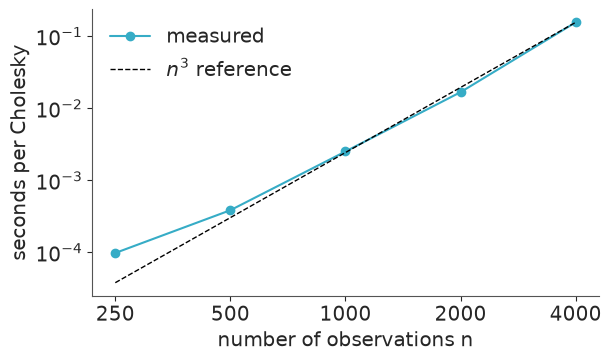

In [11]:
sizes = np.array([250, 500, 1000, 2000, 4000])
chol_seconds = []
for n in sizes:
    x = np.sort(rng.uniform(0, 60, n))[:, None]
    # Matern-5/2 kernel written out in NumPy: evaluating PyMC's symbolic kernel here would
    # compile a function that keeps ~2 GB of intermediates alive for the rest of the notebook
    r = np.sqrt(5.0) * np.abs(x - x.T) / 7.0
    K = (1.0 + r + r**2 / 3.0) * np.exp(-r) + 0.2 * np.eye(n)
    del r
    best = np.inf
    for _ in range(3):  # best of three, to reduce timing noise
        start = time.perf_counter()
        np.linalg.cholesky(K)
        best = min(best, time.perf_counter() - start)
    chol_seconds.append(best)
del K

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.loglog(sizes, chol_seconds, "o-", label="measured")
ax.loglog(sizes, chol_seconds[-1] * (sizes / sizes[-1]) ** 3.0, "k--", lw=1, label="$n^3$ reference")
ax.set(xlabel="number of observations n", ylabel="seconds per Cholesky")
ax.set_xticks(sizes, labels=[str(n) for n in sizes])
ax.minorticks_off()
ax.legend();

print(pd.Series(chol_seconds, index=sizes, name="seconds").round(4).to_string())

For large $n$ the measured line runs parallel to the $n^3$ reference: doubling the data
multiplies the cost by about eight. 133 points are nothing, a few thousand is a coffee
break per fit, tens of thousands is not feasible. And if the likelihood is not Normal, or
the GP is one *component* of a bigger model (as it will be in section 7 and in challenge
C08), $f$ cannot be integrated out at all: you need `pm.gp.Latent`, which adds $n$ strongly
correlated parameters on top of the $O(n^3)$ cost.

## 6 · The Hilbert-space approximation (HSGP)

The idea (Solin & Särkkä 2020; Riutort-Mayol et al. 2022): on an interval $[-L, L]$, any
stationary GP can be approximated by a **linear model with $m$ fixed basis functions**,

$$f(t) \approx \sum_{j=1}^{m} \sqrt{S_\theta\big(\sqrt{\lambda_j}\big)}\;\phi_j(t)\;\beta_j,
\qquad \beta_j \sim \text{Normal}(0, 1),$$

where $\phi_j(t) = \sqrt{1/L}\,\sin\!\big(\sqrt{\lambda_j}\,(t + L)\big)$ are sine waves of
increasing frequency $\sqrt{\lambda_j} = j\pi / 2L$, and $S_\theta$ is the kernel's
**power spectral density** - how much variance the kernel puts at each frequency.

- The basis $\phi_j$ does **not** depend on the hyperparameters: it is computed once.
- $\ell$ and $\eta$ only enter through the weights $\sqrt{S_\theta}$: a long lengthscale
  switches the high-frequency sines off, a short one turns them on.
- Cost per gradient: $O(nm)$ instead of $O(n^3)$. It is just a regression.

Look at both ingredients:

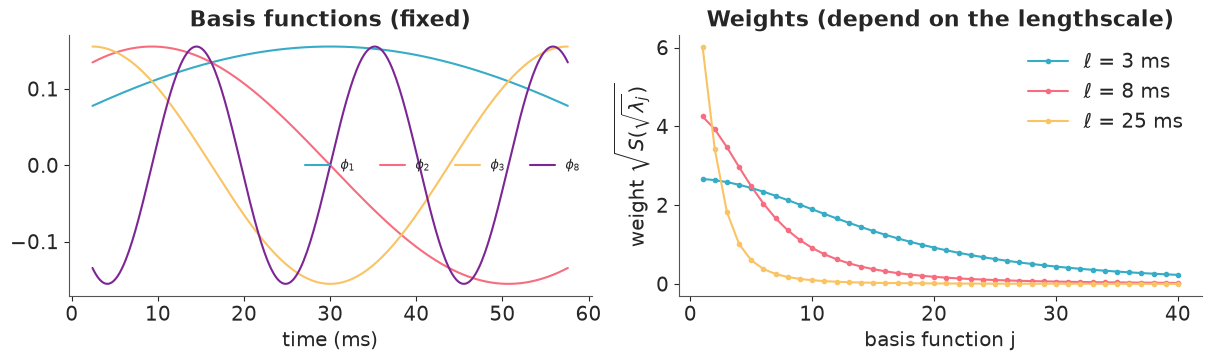

In [12]:
from pymc.gp.hsgp_approx import calc_eigenvalues, calc_eigenvectors

t_center = (t.max() + t.min()) / 2
half_range = (t.max() - t.min()) / 2
tc_grid = np.linspace(-half_range, half_range, 300)[:, None]  # HSGP works on centred inputs


def hsgp_pieces(m, c, ell):
    """Basis functions on tc_grid and sqrt-PSD weights of a unit-amplitude Matern52."""
    L = np.array([c * half_range])
    eigvals = calc_eigenvalues(L, [m])
    phi = calc_eigenvectors(tc_grid, L, eigvals, [m])
    phi = phi.eval() if hasattr(phi, "eval") else np.asarray(phi)
    psd = pm.gp.cov.Matern52(1, ls=ell).power_spectral_density(np.sqrt(eigvals)).eval().ravel()
    return phi, psd


phi, _ = hsgp_pieces(m=40, c=1.5, ell=1.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for j in [0, 1, 2, 7]:
    axes[0].plot(tc_grid + t_center, phi[:, j], label=f"$\\phi_{{{j + 1}}}$")
axes[0].set(xlabel="time (ms)", title="Basis functions (fixed)")
axes[0].legend(ncol=4, fontsize=9)
for ell_i in [3, 8, 25]:
    _, psd = hsgp_pieces(m=40, c=1.5, ell=ell_i)
    axes[1].plot(np.arange(1, 41), np.sqrt(psd), "o-", ms=3, label=f"$\\ell$ = {ell_i} ms")
axes[1].set(xlabel="basis function j", ylabel="weight $\\sqrt{S(\\sqrt{\\lambda_j})}$",
            title="Weights (depend on the lengthscale)")
axes[1].legend();

With $\ell = 25$ ms only the first handful of sines matter; with $\ell = 3$ ms the weights
are still far from zero at $j = 40$, so truncating there would throw away real wiggliness.

### Choosing `m` and `c`

Two knobs, two failure modes:

- **`c`** sets the boundary $L = c \times$ (half-range of the inputs). The sines are forced
  to zero at $\pm L$, so $f$ is pinned there. For **long** lengthscales that pinning is felt
  far inside the domain: you need a larger `c`. If you will predict outside the training
  range, that range must be inside $[-L, L]$ too.
- **`m`** is the number of sines. **Short** lengthscales need high frequencies: larger `m`.
  And a larger `c` stretches the sines, so it *also* demands a larger `m`.

PyMC ships the heuristic from Riutort-Mayol et al. Feed it the range of inputs and the
range of lengthscales your **prior** considers plausible:

In [13]:
m_rec, c_rec = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[t.min(), t.max()], lengthscale_range=[3, 25], cov_func="matern52"
)
print(f"recommended: m = {m_rec}, c = {c_rec:.2f}")

recommended: m = 90, c = 3.71


Trust, but verify. The approximation implies a covariance matrix
$\Phi\,\text{diag}(S)\,\Phi^\top$ that we can compare with the true kernel directly, for the
recommended setting and for a stingy one. Top row: the covariance between the centre of
the record and every other time. Bottom row: the prior variance of $f(t)$ itself, which
should be 1 everywhere.

ell =  3 ms, m = 90, c = 3.7: largest error anywhere in the covariance matrix = 0.009
ell =  3 ms, m = 15, c = 1.2: largest error anywhere in the covariance matrix = 0.112


ell =  8 ms, m = 90, c = 3.7: largest error anywhere in the covariance matrix = 0.000
ell =  8 ms, m = 15, c = 1.2: largest error anywhere in the covariance matrix = 0.335
ell = 25 ms, m = 90, c = 3.7: largest error anywhere in the covariance matrix = 0.000
ell = 25 ms, m = 15, c = 1.2: largest error anywhere in the covariance matrix = 0.862


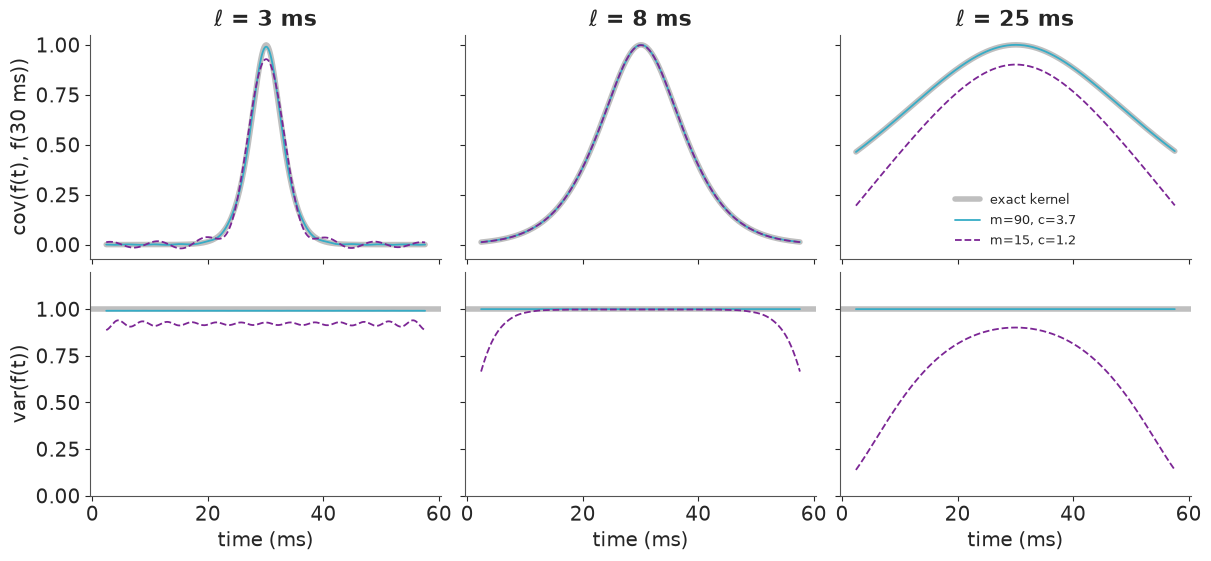

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True, sharey="row")
mid = len(tc_grid) // 2
settings = [((m_rec, c_rec), "C0-"), ((15, 1.2), "C3--")]
for col, ell_i in enumerate([3, 8, 25]):
    K_true = pm.gp.cov.Matern52(1, ls=ell_i)(tc_grid).eval()
    axes[0, col].plot(tc_grid + t_center, K_true[mid], "k", lw=4, alpha=0.25, label="exact kernel")
    axes[1, col].axhline(1, color="k", lw=4, alpha=0.25)
    for (m_i, c_i), style in settings:
        phi, psd = hsgp_pieces(m_i, c_i, ell_i)
        K_approx = phi @ np.diag(psd) @ phi.T
        axes[0, col].plot(tc_grid + t_center, K_approx[mid], style, lw=1.3, label=f"m={m_i}, c={c_i:.1f}")
        axes[1, col].plot(tc_grid + t_center, np.diag(K_approx), style, lw=1.3)
        print(f"ell = {ell_i:>2} ms, m = {m_i:>2}, c = {c_i:.1f}: "
              f"largest error anywhere in the covariance matrix = {np.abs(K_approx - K_true).max():.3f}")
    axes[0, col].set_title(f"$\\ell$ = {ell_i} ms")
    axes[1, col].set(xlabel="time (ms)", ylim=(0, 1.2))
axes[0, 0].set_ylabel("cov(f(t), f(30 ms))")
axes[1, 0].set_ylabel("var(f(t))")
axes[0, 2].legend(fontsize=9, loc="lower center");

The recommended setting reproduces the kernel at all three lengthscales: the largest error
anywhere in the covariance matrix is 0.009, at $\ell = 3$ ms. The stingy one (`m=15`,
`c=1.2`) fails in **two different ways**:

- Too few sines (`m`): at $\ell = 3$ ms it lacks the high frequencies to form a narrow peak.
  The peak comes out too low, with ripples either side, and the prior variance sits below 1.
- Boundary too close (`c`): the variance is pinched towards zero at the edges of the record.
  At $\ell = 8$ ms that only hurts the first and last few milliseconds; at $\ell = 25$ ms
  it ruins the whole domain (largest error 0.86 - the approximation is nothing like the
  kernel we asked for). A model fitted with it would be confidently flat near the edges.

### Fitting it

`gp.prior("f", X)` builds the regression above and returns $f$ at the rows of `X`. Three
details matter:

1. **`X` is a `pm.Data` container.** `HSGP` records the centre and the boundary `L` from the
   *training* inputs when the model is built, so that swapping in new inputs later with
   `pm.set_data` evaluates the *same* basis at new locations. (If you want the basis and the
   weights themselves - for instance to share one basis between several GPs -
   `gp.prior_linearized(X)` returns them and you write `phi @ (beta * sqrt_psd)` yourself.)
2. The likelihood gets `shape=f.shape` so that it resizes with the data.
3. **Freeze the data while sampling.** A `pm.Data` container may change at any time, so the
   compiled model recomputes the whole sine basis at *every gradient evaluation* - which
   throws away the main selling point of HSGP. `freeze_dims_and_data(model)` returns a copy
   in which the data are constants, so the basis is computed once. Sample from the frozen
   copy; keep the original for `pm.set_data`. We time both below.

In [15]:
def build_hsgp(parametrization):
    with pm.Model() as model:
        X = pm.Data("X", t[:, None])
        ell = pm.InverseGamma("ell", alpha=ELL_ALPHA, beta=ELL_BETA)
        eta = pm.HalfNormal("eta", 1.5)
        sigma = pm.HalfNormal("sigma", 1)

        cov = eta**2 * pm.gp.cov.Matern52(1, ls=ell)
        gp = pm.gp.HSGP(m=[m_rec], c=c_rec, parametrization=parametrization, cov_func=cov)
        f = gp.prior("f", X=X)
        pm.Normal("y", f, sigma, observed=y, shape=f.shape)
    return model


hsgp_nc_model = build_hsgp("noncentered")

start = time.time()
with hsgp_nc_model:  # pm.Data left as it is: the basis is rebuilt at every gradient
    pm.sample(random_seed=RANDOM_SEED, progressbar=False)
unfrozen_seconds = time.time() - start

start = time.time()
with freeze_dims_and_data(hsgp_nc_model):
    hsgp_nc_idata = pm.sample(random_seed=RANDOM_SEED)
frozen_seconds = time.time() - start

print(f"sampling wall time: {unfrozen_seconds:.0f}s with live pm.Data, {frozen_seconds:.0f}s frozen")

print("divergences:", int(hsgp_nc_idata.sample_stats["diverging"].sum()))
az.summary(hsgp_nc_idata, var_names=["ell", "eta", "sigma"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [ell, eta, sigma, f_hsgp_coeffs]


NUTS[nutpie]: [eta, ell, f_hsgp_coeffs, sigma]


sampling wall time: 6s with live pm.Data, 1s frozen
divergences: 165


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,7.45,1.57,4.87,10.47,206.51,56.67,1.03,0.12,0.08
eta,1.19,0.40,0.55,1.92,105.77,42.09,1.05,0.05,0.07
sigma,0.47,0.03,0.42,0.53,1684.02,1762.44,1.01,0.00,0.00


First the timing: freezing the data made sampling several times faster even on this tiny
problem (both numbers include a few seconds of compilation), and the gap grows with $n$ and
$m$. From here on we always sample from the frozen copy.

The estimates agree with the exact GP, but look at the divergence count, the `r_hat` and the
ESS of `ell` and `eta`, an order of magnitude below that of `sigma`. You have seen this in
E02: it is the centred/non-centred story with the roles reversed.

By default HSGP is **non-centred**: $\beta_j \sim \text{Normal}(0, 1)$ and
$f = \Phi\,(\sqrt{S_\theta} \odot \beta)$. That is the right choice when the data say little
about $f$. Here the data pin the curve down tightly, so the *products*
$\sqrt{S_\theta(j)}\,\beta_j$ are well determined - and every change in $\ell$ or $\eta$ must
be compensated by all the $\beta_j$ at once. That is a curved, funnel-like posterior.
The **centred** form samples the products directly, $\beta_j \sim \text{Normal}(0, \sqrt{S_\theta(j)})$:

In [16]:
hsgp_model = build_hsgp("centered")
with freeze_dims_and_data(hsgp_model):
    hsgp_idata = pm.sample(draws=2000, random_seed=RANDOM_SEED)  # 2000 draws: see below

print("divergences:", int(hsgp_idata.sample_stats["diverging"].sum()))
az.summary(hsgp_idata, var_names=["ell", "eta", "sigma"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [eta, ell, f_hsgp_coeffs, sigma]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,7.51,1.69,4.55,10.70,559.72,1077.55,1.01,0.07,0.04
eta,1.18,0.38,0.61,1.90,1105.33,2050.90,1.00,0.01,0.01
sigma,0.47,0.03,0.41,0.53,11209.49,5611.28,1.00,0.00,0.00


The divergences are gone and `r_hat` is back to 1.00-1.01. That is what matters most:
divergences mean the sampler is *missing* part of the posterior, which biases everything
downstream.

The centred form is not free, though: the ESS of `ell` is still well under a tenth of the
number of draws. Of the 90 coefficients only the low-frequency ones are pinned down by the
data; the high-frequency rest are governed by their prior, and for *those* the centred form
is the funnel (their prior scale $\sqrt{S_\theta(j)}$ moves with $\ell$). Neither
parametrisation is right for all 90 at once. Slow-but-unbiased mixing is the better problem
to have - it is cured by running longer, which is why this fit uses 2000 draws per chain.

### Predicting with `pm.set_data`

No `conditional` needed: $f$ is a deterministic function of `X` and the coefficients, so we
swap `X` and ask for `f` and `y` at the new inputs.

In [17]:
with hsgp_model:
    pm.compute_log_likelihood(hsgp_idata)  # for LOO later; do this while X is still the training data
    pm.sample_posterior_predictive(hsgp_idata, extend_inferencedata=True, random_seed=RANDOM_SEED)
    pm.set_data({"X": t_grid[:, None]})
    hsgp_pred = pm.sample_posterior_predictive(
        hsgp_idata, var_names=["f", "y"], predictions=True, random_seed=RANDOM_SEED
    )

Sampling: [y]


Sampling: [y]


### Does it agree with the exact GP?

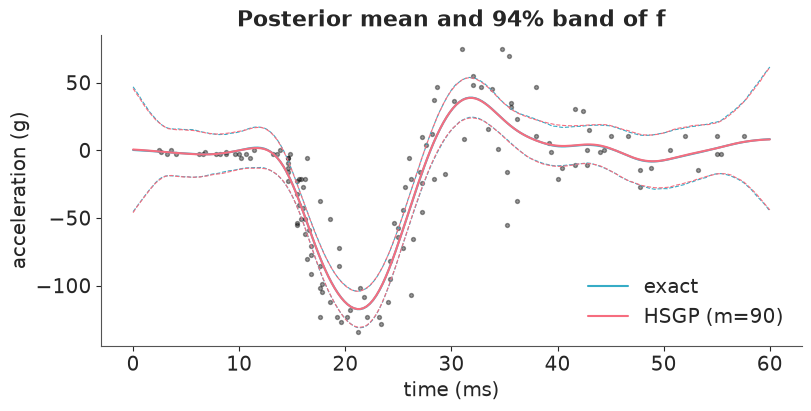

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
for da, color, label in [(exact_pred.posterior_predictive["f_new"], "C0", "exact"),
                         (hsgp_pred.predictions["f"], "C1", f"HSGP (m={m_rec})")]:
    mean, lo, hi = band(da)
    ax.plot(t_grid, mean, color=color, label=label)
    ax.plot(t_grid, lo, color=color, lw=0.8, ls="--")
    ax.plot(t_grid, hi, color=color, lw=0.8, ls="--")
ax.scatter(t, y * ACCEL_SD, s=8, color="k", alpha=0.4)
ax.set(xlabel="time (ms)", ylabel="acceleration (g)", title="Posterior mean and 94% band of f")
ax.legend();

In [19]:
f_gap = np.abs(band(exact_pred.posterior_predictive["f_new"])[0] - band(hsgp_pred.predictions["f"])[0]).max()
print(f"largest gap between the two posterior means of f: {f_gap:.2f} g")
print(f"sampling wall time, 1000 draws: exact {exact_seconds:.0f}s, HSGP {frozen_seconds:.0f}s (frozen)")

rows = {}
for name, idata in [("exact", exact_idata), ("HSGP", hsgp_idata)]:
    post = az.extract(idata, var_names=["ell", "eta", "sigma"])
    rows[name] = {v: f"{float(post[v].mean()):.2f} ± {float(post[v].std()):.2f}" for v in ["ell", "eta", "sigma"]}
pd.DataFrame(rows).T.rename_axis("posterior mean ± sd")

largest gap between the two posterior means of f: 0.42 g
sampling wall time, 1000 draws: exact 5s, HSGP 1s (frozen)


,ell,eta,sigma
posterior mean ± sd,,,
exact,7.62 ± 1.74,1.21 ± 0.40,0.47 ± 0.03
HSGP,7.51 ± 1.69,1.18 ± 0.38,0.47 ± 0.03


The curves and bands are on top of each other and the hyperparameters match to within Monte
Carlo error. On 133 points speed is not the argument - both models fit in a few seconds,
most of it compilation, and your timings will differ. The pay-off is elsewhere: HSGP's cost
grows linearly in $n$ instead of cubically, and because $f$ is now an ordinary deterministic
node, we can use GPs as **building blocks** - which is what we do next.

When *not* to use HSGP: lengthscales that are tiny relative to the domain (the required `m`
explodes), more than 2-3 input dimensions (`m` is per dimension and multiplies), or
non-stationary kernels (no spectral density).

## 7 · The pay-off: a GP for the noise, too

The constant-noise band in section 4 was wrong. Let the noise level itself be a smooth
function of time, modelled on the log scale so that it stays positive:

$$
\begin{aligned}
y_i &\sim \text{Normal}\big(f(t_i),\ \sigma(t_i)\big) \\
f &\sim \text{GP}(0, k_f) \\
\log \sigma(t) &= s_0 + g(t), \qquad g \sim \text{GP}(0, k_g)
\end{aligned}
$$

With exact GPs this is unpleasant ($\sigma(t)$ sits inside the covariance matrix, and $g$
must be a 133-dimensional `Latent` GP). With HSGP it is ten more lines.

Priors: $s_0 \sim \text{Normal}(-1, 1)$ puts the typical noise around $e^{-1} \approx 0.4$
sd units with a factor of $e$ either way. `eta_g ~ HalfNormal(1.5)` lets the noise vary over
time by a factor of up to $e^{\pm 3}$ - wide, because the plot suggests a change of more
than tenfold. Same lengthscale prior as $f$.

Parametrisation, following the reasoning above: $f$ is strongly informed by the data →
**centred**; $g$ is only weakly informed (a variance is much harder to learn than a mean)
→ **non-centred**. Two GPs multiply the awkward geometry, so we also raise `target_accept`
and, as before, take 2000 draws per chain.

In [20]:
with pm.Model() as hetero_model:
    X = pm.Data("X", t[:, None])

    ell = pm.InverseGamma("ell", alpha=ELL_ALPHA, beta=ELL_BETA)
    eta = pm.HalfNormal("eta", 1.5)
    gp_f = pm.gp.HSGP(m=[m_rec], c=c_rec, parametrization="centered",
                      cov_func=eta**2 * pm.gp.cov.Matern52(1, ls=ell))
    f = gp_f.prior("f", X=X)

    ell_g = pm.InverseGamma("ell_g", alpha=ELL_ALPHA, beta=ELL_BETA)
    eta_g = pm.HalfNormal("eta_g", 1.5)
    s0 = pm.Normal("s0", -1, 1)
    gp_g = pm.gp.HSGP(m=[m_rec], c=c_rec, parametrization="noncentered",
                      cov_func=eta_g**2 * pm.gp.cov.Matern52(1, ls=ell_g))
    g = gp_g.prior("g", X=X)
    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(s0 + g))

    pm.Normal("y", f, sigma_t, observed=y, shape=f.shape)


with freeze_dims_and_data(hetero_model):
    hetero_idata = pm.sample(draws=2000, target_accept=0.95, random_seed=RANDOM_SEED)

print("divergences:", int(hetero_idata.sample_stats["diverging"].sum()))
az.summary(hetero_idata, var_names=["ell", "eta", "ell_g", "eta_g", "s0"],
           ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [eta_g, ell_g, g_hsgp_coeffs, s0, eta, ell, f_hsgp_coeffs]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,7.57,1.60,4.69,10.56,633.09,1039.29,1.01,0.06,0.03
eta,1.15,0.38,0.59,1.84,1450.06,2192.69,1.00,0.01,0.01
ell_g,8.95,2.58,4.66,13.68,6139.42,6028.15,1.00,0.03,0.04
eta_g,1.46,0.48,0.73,2.33,6095.39,5880.70,1.00,0.01,0.01
s0,-1.42,0.61,-2.51,-0.19,7713.84,5174.31,1.00,0.01,0.01


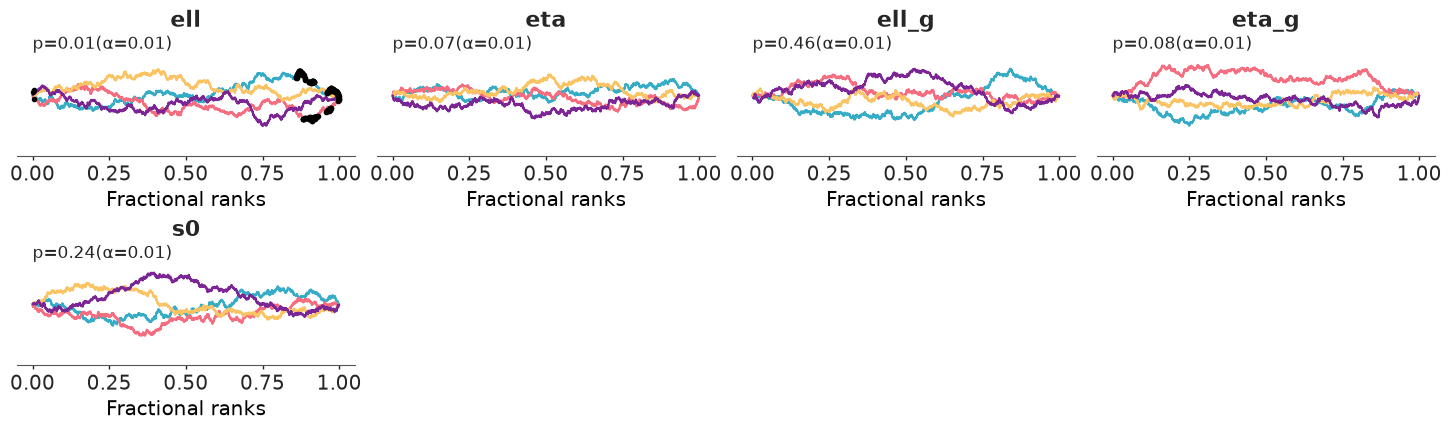

In [21]:
az.plot_rank(hetero_idata, var_names=["ell", "eta", "ell_g", "eta_g", "s0"]);

No divergences and `r_hat` at most 1.01. The weakest parameter is `ell` again: it has the
lowest ESS, and its rank plot touches the edge of the 99% envelope at the high end (marked
in black) - the slow mixing of the centred form that we met above. For the curve and the
bands, which is what we use below, that is good enough; if $\ell$ itself were the quantity
of interest we would run longer.

In [22]:
with hetero_model:
    pm.compute_log_likelihood(hetero_idata)
    pm.sample_posterior_predictive(hetero_idata, extend_inferencedata=True, random_seed=RANDOM_SEED)
    pm.set_data({"X": t_grid[:, None]})
    hetero_pred = pm.sample_posterior_predictive(
        hetero_idata, var_names=["f", "y", "sigma_t"], predictions=True, random_seed=RANDOM_SEED
    )

Sampling: [y]


Sampling: [y]


### Posterior predictive check: whose bands are right?

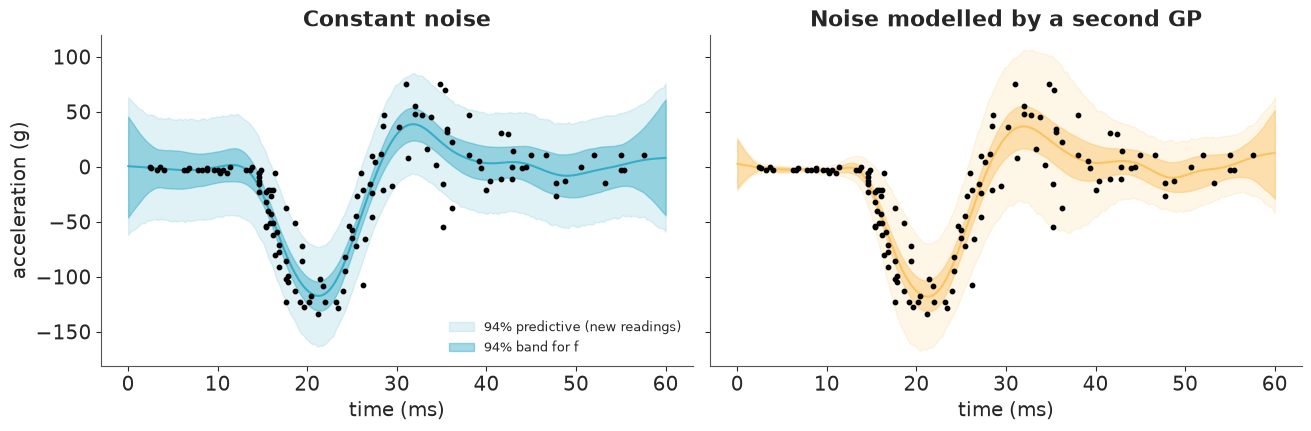

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
plot_fit(hsgp_pred.predictions["f"], hsgp_pred.predictions["y"], axes[0], color="C0",
         title="Constant noise")
plot_fit(hetero_pred.predictions["f"], hetero_pred.predictions["y"], axes[1], color="C2",
         title="Noise modelled by a second GP")
axes[1].set_ylabel("")
axes[0].legend(loc="lower right", fontsize=9);

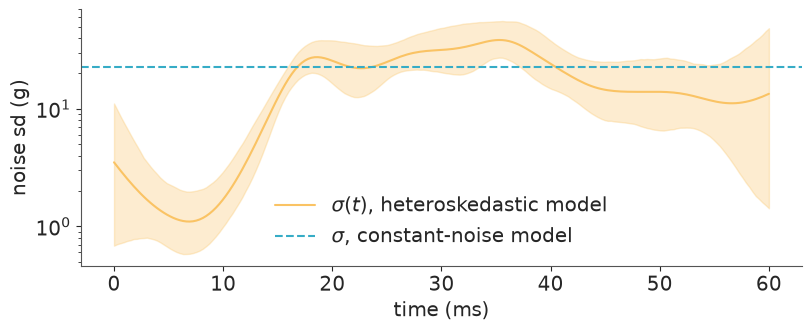

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.2))
s_mean, s_lo, s_hi = band(hetero_pred.predictions["sigma_t"])
ax.fill_between(t_grid, s_lo, s_hi, color="C2", alpha=0.3)
ax.plot(t_grid, s_mean, color="C2", label="$\\sigma(t)$, heteroskedastic model")
ax.axhline(float(hsgp_idata.posterior["sigma"].mean()) * ACCEL_SD, color="C0", ls="--",
           label="$\\sigma$, constant-noise model")
ax.set(xlabel="time (ms)", ylabel="noise sd (g)", yscale="log")
ax.legend();

A picture is persuasive; a number is checkable. How many readings fall inside each model's
own 90% predictive interval, by phase of the crash? A calibrated model scores about 90%
**in every phase**, not just on average.

In [25]:
phase = pd.cut(t, [0, 13, 30, 40, 60],
               labels=["before impact (<13 ms)", "impact (13-30 ms)", "rebound (30-40 ms)", "tail (>40 ms)"])


def coverage_by_phase(idata, prob=0.9):
    y_rep = idata.posterior_predictive["y"]
    lo, hi = y_rep.quantile([(1 - prob) / 2, (1 + prob) / 2], dim=("chain", "draw")).to_numpy()
    inside = (y >= lo) & (y <= hi)
    width = (hi - lo) * ACCEL_SD
    out = pd.DataFrame({"inside": inside, "width": width}).groupby(phase, observed=True).agg(
        n=("inside", "size"), coverage=("inside", "mean"), mean_width_g=("width", "mean"))
    return out.round(2)


pd.concat({"constant noise": coverage_by_phase(hsgp_idata),
           "heteroskedastic": coverage_by_phase(hetero_idata)}, axis=1)

constant noise                       heteroskedastic  \
                                    n coverage mean_width_g               n   
before impact (<13 ms)             18     1.00        80.28              18   
impact (13-30 ms)                  72     0.90        77.38              72   
rebound (30-40 ms)                 22     0.82        78.69              22   
tail (>40 ms)                      21     1.00        81.33              21   

                                              
                       coverage mean_width_g  
before impact (<13 ms)     1.00         6.12  
impact (13-30 ms)          0.94        75.36  
rebound (30-40 ms)         0.95       119.17  
tail (>40 ms)              1.00        55.88

The constant-noise model has one width for everything: about 80 g. Before the impact that
is an interval 80 g wide around readings that vary by a couple of g. It covers 100% of
them, but over-coverage is a failure too: this model would not notice a sensor fault ten
times larger than anything in the data. In the rebound, where the scatter is largest, the
same 80 g is too narrow and coverage drops to 82%.

The heteroskedastic model's interval is 6 g wide before the impact, about 120 g in the
rebound and 56 g in the tail, and it covers 94-100% of the readings in every phase. That is
slightly conservative for a nominal 90% - with about 20 readings in three of the phases,
100% instead of 90% is a matter of two readings - but it is never too narrow, and its widths
follow the data.

### LOO

Pointwise LOO needs a pointwise likelihood, which is another thing HSGP gives us. (The
`Marginal` model has a single 133-dimensional MvNormal "observation", so `az.loo` has
nothing to leave out.)

In [26]:
comparison = az.compare({"constant noise": hsgp_idata, "heteroskedastic": hetero_idata})
comparison

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
heteroskedastic,0,0.0,0.0,NaN,,5 k̂ > 0.70,22.5,-40.0,14.0,1.0
constant noise,1,-50.0,10.0,1.0,,,12.0,-90.0,10.0,0.0


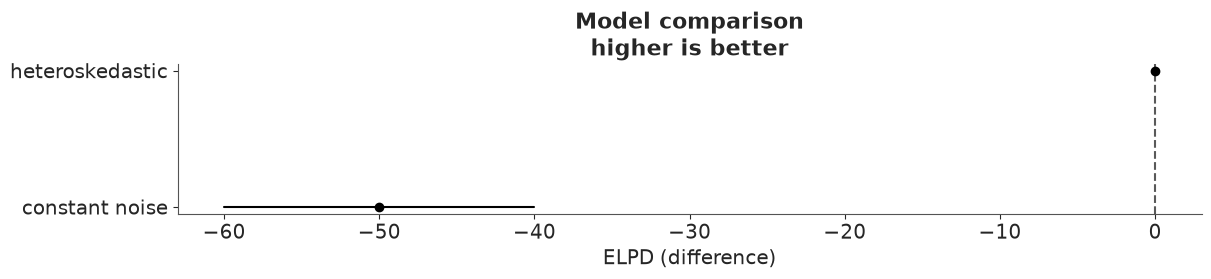

In [27]:
az.plot_compare(comparison);

The heteroskedastic model wins by an `elpd` margin several times its standard error `dse`,
despite spending more effective parameters (`p`). If LOO warns about a few Pareto-$k$ values
above 0.7 for this model, that is expected: with a flexible noise process, a single reading
in a sparse stretch has a lot of influence on the local $\sigma(t)$, which is precisely the
situation where importance sampling struggles. The margin here is far too large for that to
change the verdict; when it is close, refit for the flagged points with `az.reloo` or use
`az.loo_kfold`.

**What did we learn about the crash?** The mean curve barely changed between models. What
changed is the honesty of the uncertainty: a helmet engineer reading the first figure would
conclude that readings are uncertain by tens of g at all times; the second says the rig is
precise to a few g and the large scatter is a *feature of the impact phase itself*.

### Try it yourself

1. Replace `Matern52` with `ExpQuad` in the exact model and the centred HSGP. Compare the
   fits, then explain what goes wrong in the centred HSGP (hint: plot the `ExpQuad` spectral
   density weights for large $j$ the way we did in section 6).
2. Halve and double `m` (keeping `c`), and set `c = 1.2` (keeping `m`). Which posterior
   summaries move first - $\ell$, $\eta$, or the curve itself?
3. The readings look heavier-tailed than Normal during the rebound. Swap the likelihood of
   the heteroskedastic model for a `StudentT` with an estimated `nu`. Does LOO prefer it,
   and do the Pareto-$k$ warnings go away?

Next: challenge **C08**, where HSGPs become components of a structural time-series model
that has to *forecast* - something a stationary GP on its own turns out to be bad at.